In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import csv
import numpy as np
import ast
import seaborn as sns
import ast

from sklearn.metrics import mean_squared_error


TASC_VColor         = "#57B8FF"  # keep
TASC_permute_VColor = "#2176AE"  # keep
SC_VColor           = "#7ED957"  # fresher green, balanced against blue tones
RSC_VColor          = "#FF9F40"  # brighter orange, closer in vibrancy
CIM_VColor          = "#E255A1"  # vivid magenta, still distinct but harmonized


In [2]:
arr = np.array([
    2.5803771018981934, 4.2095947265625, 4.4525017738342285, 12.95372200012207,
    31.328702926635742, 55.19633865356445, 9.935724258422852, 16.888704299926758,
    5.613946914672852, 43.994049072265625, 12.950848579406738, 18.034343719482422,
    170.79302978515625, 11.907007217407227, 11.357678413391113, 21.813426971435547,
    6.931178092956543, 5.199104309082031, 8.695411682128906, 5.898716449737549,
    59.65138244628906, 54.185150146484375, 3.282482862472534, 152.8282470703125,
    41.100196838378906, 23.462308883666992, 36.029727935791016, 5.260776042938232,
    26.48195457458496, 8.290522575378418, 8.434488296508789, 21.060447692871094,
    18.17054557800293, 6.055248737335205, 57.814239501953125, 14.09340763092041,
    11.96905517578125, 6.395833969116211, 73.983642578125
])

In [4]:
print(arr.mean())
print(arr.std())
print(arr.min())
print(arr.max())
print(np.median(arr))

27.930360653461555
36.17611993915436
2.5803771018981934
170.79302978515625
12.95372200012207


In [5]:
df = pd.read_csv("../../aistats_exp1/logs/exp1_try7.csv")
header = ["seed_datagen", "seed_learning", "d_true", "N", "T", "T0", "N1", "d",
        "high_covariance", "loglikelihood", "loglikelihood_permute",
        "pred_tasc", "pred_tasc_permute", "pred_rsc", "pred_sc", "pred_cim", "cim_posterior_lower", "cim_posterior_upper",
        "tasc_target_var_estimates", "tasc_permute_target_var_estimates",
        "R_tasc", "R_tasc_permute",
        "ys", "ys_signal",
        ]

df = df.fillna("all small")

# Convert string representation of lists back to lists
list_cols = ['pred_tasc', 'pred_tasc_permute',
       'pred_rsc', 'pred_sc', 'pred_cim', 'cim_posterior_lower',
       'cim_posterior_upper', 'tasc_target_var_estimates','tasc_permute_target_var_estimates', 'ys', 'ys_signal']

for col in list_cols:
    df[col] = df[col].apply(ast.literal_eval)

# tasc lower/upper bound
df["tasc_upper"] = df.apply(lambda row: row["pred_tasc"] + 1.96 * np.sqrt(row["tasc_target_var_estimates"]), axis=1)
df["tasc_lower"] = df.apply(lambda row: row["pred_tasc"] - 1.96 * np.sqrt(row["tasc_target_var_estimates"]), axis=1)

# Compute RMSE for each method
pred_cols = ['pred_tasc', 'pred_tasc_permute', 'pred_rsc', 'pred_sc', 'pred_cim']

for col in pred_cols:
    df["rmse_"+col] = df.apply(
        lambda row: mean_squared_error(
            row["ys_signal"][row["T0"]:], row[col][row["T0"]:]
            # row["ys"][row["T0"]:], row[col][row["T0"]:]
        ),
        axis=1
    )

df.head()

,seed_datagen,seed_learning,d_true,N,T,T0,N1,d,high_covariance,loglikelihood,...,R_tasc_permute,ys,ys_signal,tasc_upper,tasc_lower,rmse_pred_tasc,rmse_pred_tasc_permute,rmse_pred_rsc,rmse_pred_sc,rmse_pred_cim
0,0,1000,5,50,100,50,1000,5,all small,-2384.538818,...,"[0.6936393976211548, 0.6519147157669067, 0.603...","[0.476845193288071, 0.4326607962739012, 0.2313...","[0.4152064033497874, 0.39397179945951416, 0.05...","[0.6900018294201292, 0.43856237611313076, 0.23...","[0.5398924510135256, 0.26157750406722813, 0.05...",0.011385,0.082804,0.002952,0.007440,0.005510
1,0,1000,5,50,100,50,1000,5,Q,-2478.348389,...,"[0.706536054611206, 0.6604067087173462, 0.6296...","[0.06999387021223565, 0.20272779411167813, -1....","[0.008355080273952037, 0.16403879729729112, -1...","[0.30496135932464014, 0.5608185807575639, -1.5...","[-0.2220851538803042, -0.014647988449519478, -...",0.019130,0.026718,0.005370,0.086706,0.114980
2,0,1000,5,50,100,50,1000,5,R,-4320.210938,...,"[2.0653083324432373, 1.5140780210494995, 1.577...","[-0.06291468905292874, 0.29280921159801165, -0...","[0.4152064033497874, 0.39397179945951416, 0.05...","[1.5416068909760032, 1.4359030013989795, 0.646...","[1.0667727114562477, 0.9115050548601757, 0.086...",0.201527,0.159257,0.782660,0.310699,1.177804
3,0,1000,5,50,100,50,1000,5,both,-4451.335449,...,"[2.267975330352783, 1.4768390655517578, 1.5716...","[-0.4697660121287641, 0.06287620943578863, -2....","[0.008355080273952037, 0.16403879729729112, -1...","[0.40696167485228946, 0.819463468790167, -1.04...","[-0.22311853901854922, 0.02612587094295682, -1...",0.378236,0.854513,0.535726,0.625289,0.946605
4,1,1000,5,50,100,50,1000,5,all small,-2301.597900,...,"[0.5889309644699097, 0.6742861866950989, 0.612...","[-0.17099600592120837, 0.3900980243551298, 0.1...","[0.011434917777350685, 0.5109583683091986, 0.1...","[0.008887742402721225, 0.4216822338865696, 0.1...","[-0.03708117524044591, 0.37133235208526266, 0....",0.020527,0.025329,0.004554,0.002976,0.004951


In [6]:
# df = best_df.copy()
id_vars = ["high_covariance"]

# Map columns to method names
method_map = {
    "rmse_pred_tasc": "TASC",
    "rmse_pred_tasc_permute": "TASC-permuted",
    "rmse_pred_rsc": "RSC",
    "rmse_pred_sc": "SC",
    "rmse_pred_cim": "CIM"
}

# Melt in one go
df_long = df.melt(
    id_vars=id_vars,
    value_vars=method_map.keys(),
    value_name="rmse",
    var_name="variable"
)

# Map variable names to methods
df_long["method"] = df_long["variable"].map(method_map)

# Drop the original column identifier if not needed
df_long = df_long.drop(columns="variable")

print(df_long.shape)
df_long.head()


(2000, 3)


,high_covariance,rmse,method
0,all small,0.011385,TASC
1,Q,0.019130,TASC
2,R,0.201527,TASC
3,both,0.378236,TASC
4,all small,0.020527,TASC


                                   rmse
method        high_covariance          
TASC          Q                0.189466
              all small        0.418088
TASC-permuted Q                2.008042
              all small        0.360516


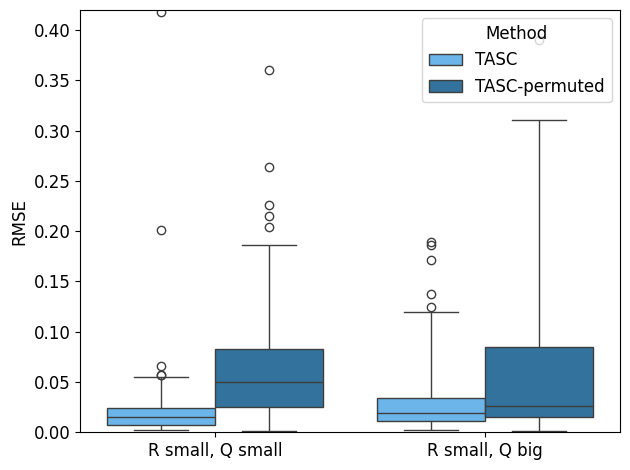

In [7]:
# small R first

df_plot = df_long[df_long["method"].isin(["TASC","TASC-permuted"])]
df_plot = df_plot[df_plot["high_covariance"].isin(["all small", "Q"])]

print(df_plot.groupby(["method","high_covariance"], group_keys=False).max())

# for outlier in ["included", "skipped"]:

#     if outlier == "skipped":
#         # Drop 5 outliers
#         df_plot = (
#             df_plot.groupby(["method","high_covariance"], group_keys=False)
#             .apply(lambda g: g.assign(rmse=drop_top_n(g["rmse"], n=5)))
#         )

xticks = [0, 1]
xtickers = ["R small, Q small", "R small, Q big"]
font = 12

# plt.figure(figsize=(9, 5))

# ax = sns.violinplot(
ax = sns.boxplot(
    data=df_plot,
    x="high_covariance", 
    y="rmse",
    hue="method",  whis = [0, 95],     
    palette={"TASC": TASC_VColor, "TASC-permuted":TASC_permute_VColor, "RSC": RSC_VColor, "SC": SC_VColor, "CIM": CIM_VColor},
    # linewidth=1.5,
    # inner="quartile",
    # cut=0
)

plt.xlabel("", fontsize=font)
plt.ylabel("RMSE", fontsize=font)
plt.xticks(xticks, xtickers, fontsize=font)
plt.yticks(fontsize=font)
plt.ylim(bottom=0, top=0.42)
plt.legend(title="Method", fontsize=font, title_fontsize=font)
plt.tight_layout()
plt.savefig('exp1_permutation_smallR.png')
# plt.savefig('exp1_permutation_smallR_{}.png'.format(outlier))
plt.show()


                                   rmse
method        high_covariance          
TASC          R                0.833213
              both             4.501200
TASC-permuted R                0.782580
              both             6.042324


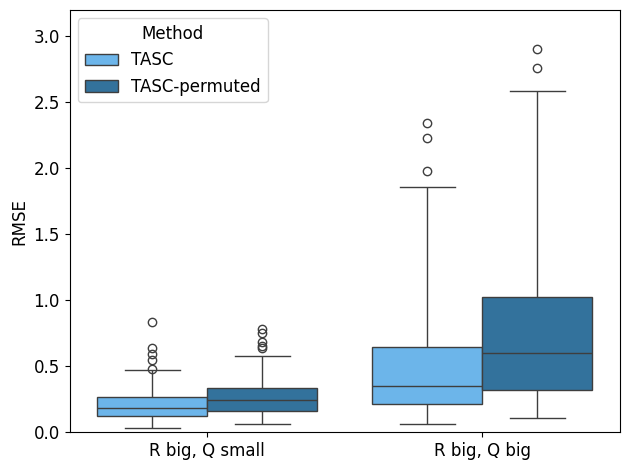

In [8]:
# big R now

df_plot = df_long[df_long["method"].isin(["TASC","TASC-permuted"])]
df_plot = df_plot[df_plot["high_covariance"].isin(["R", "both"])]

print(df_plot.groupby(["method","high_covariance"], group_keys=False).max())

# for outlier in ["included", "skipped"]:

#     if outlier == "skipped":
#         # Drop 5 outliers
#         df_plot = (
#             df_plot.groupby(["method","high_covariance"], group_keys=False)
#             .apply(lambda g: g.assign(rmse=drop_top_n(g["rmse"], n=5)))
#         )

xticks = [0, 1]
xtickers = ["R big, Q small", "R big, Q big"]
font = 12

# plt.figure(figsize=(9, 5))

# ax = sns.violinplot(
ax = sns.boxplot(
    data=df_plot,
    x="high_covariance", 
    y="rmse",
    hue="method",     whis = [0, 95],   
    palette={"TASC": TASC_VColor, "TASC-permuted":TASC_permute_VColor, "RSC": RSC_VColor, "SC": SC_VColor, "CIM": CIM_VColor},
    # linewidth=1.5,
    # inner="quartile",
    # cut=0
)

plt.xlabel("", fontsize=font)
plt.ylabel("RMSE", fontsize=font)
plt.xticks(xticks, xtickers, fontsize=font)
plt.yticks(fontsize=font)
plt.ylim(bottom=0, top=3.2)
plt.legend(title="Method", fontsize=font, title_fontsize=font)
plt.tight_layout()
plt.savefig('exp1_permutation_bigR.png')
# plt.savefig('exp1_permutation_bigR_{}.png'.format(outlier))
plt.show()


                                   rmse
method        high_covariance          
TASC          both             4.501200
TASC-permuted both             6.042324


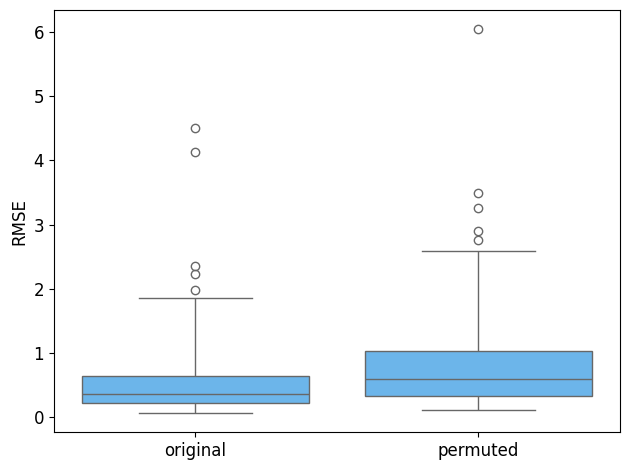

In [14]:
# big R now

df_plot = df_long[df_long["method"].isin(["TASC","TASC-permuted"])]
df_plot = df_plot[df_plot["high_covariance"].isin(["both"])]

print(df_plot.groupby(["method","high_covariance"], group_keys=False).max())

# for outlier in ["included", "skipped"]:

#     if outlier == "skipped":
#         # Drop 5 outliers
#         df_plot = (
#             df_plot.groupby(["method","high_covariance"], group_keys=False)
#             .apply(lambda g: g.assign(rmse=drop_top_n(g["rmse"], n=5)))
#         )

xticks = [0, 1]
xtickers = ["original", "permuted"]
font = 12

# plt.figure(figsize=(9, 5))

# ax = sns.violinplot(
ax = sns.boxplot(
    data=df_plot,
    x="method", 
    y="rmse",
    # hue="method",
    whis = [0, 95],
    color = TASC_VColor,
    # palette={"TASC": TASC_VColor, "TASC-permuted":TASC_permute_VColor, "RSC": RSC_VColor, "SC": SC_VColor, "CIM": CIM_VColor},
    # linewidth=1.5,
    # inner="quartile",
    # cut=0
)

plt.xlabel("", fontsize=font)
plt.ylabel("RMSE", fontsize=font)
plt.xticks(xticks, xtickers, fontsize=font)
plt.yticks(fontsize=font)
# plt.ylim(bottom=0, top=3.2)
# plt.legend(title="Method", fontsize=font, title_fontsize=font)
plt.tight_layout()
plt.savefig('exp1_permutation.png')
# plt.savefig('exp1_permutation_bigR_{}.png'.format(outlier))
plt.show()


In [18]:
df_plot[df_plot.method=="TASC"].describe()


,rmse
count,100.000000
mean,0.592979
std,0.706797
min,0.062666
25%,0.213986
50%,0.352962
75%,0.646864
max,4.501200


In [21]:
df_plot[df_plot.method=="TASC-permuted"].describe()

,rmse
count,100.000000
mean,0.880845
std,0.889083
min,0.108868
25%,0.321362
50%,0.599116
75%,1.025582
max,6.042324


In [24]:
0.880845/ 0.592979

1.4854573264820508

In [23]:
0.889083 /0.706797

1.2579043204767422